# Stock Price Prediction using Machine Learning and Time Series Analysis

**Course Project — Machine Learning**

## 1. Objective
The goal of this project is to predict future stock closing prices using historical
price and volume data. We approach the problem from three complementary angles that
are commonly compared in the literature:

1. **Classical time series modeling** — ARIMA (AutoRegressive Integrated Moving Average)
2. **Feature-based machine learning** — Linear Regression, Decision Tree, Random Forest,
   and Gradient Boosting regressors trained on engineered technical indicators
3. **Deep learning** — a Long Short-Term Memory (LSTM) recurrent neural network that
   learns temporal patterns directly from sequences of past prices

We then compare all models on the same held-out test period using standard
regression metrics (RMSE, MAE, MAPE, R²) and discuss their strengths and weaknesses.

## 2. Problem Statement
Given the historical Open/High/Low/Close/Volume (OHLCV) data of Apple Inc. (AAPL) stock,
predict the **next day's closing price**.

> **Note on scope:** Stock prices are notoriously close to a random walk, and no model
> here is a trading system or financial advice — this is an educational exercise in
> applying ML/time-series techniques to a real, noisy, non-stationary dataset.

## 3. Dataset
This notebook uses **real historical AAPL daily price data** (Open/High/Low/Close/Volume),
covering **2015-01-02 to 2025-12-31** (2,766 trading days). Unlike an earlier draft of
this project that had to fall back on synthetic data (no internet access in that
environment), this version reads the real dataset directly from a local CSV file, so no
`yfinance` download is required.

## 4. Project Pipeline
1. Data acquisition
2. Exploratory Data Analysis (EDA)
3. Feature engineering (technical indicators)
4. Train/test split (time-based, no shuffling)
5. Baseline model (naive persistence)
6. Model building: ARIMA, Linear Regression, Decision Tree, Random Forest, Gradient Boosting, LSTM
7. Evaluation and comparison
8. Conclusion & future work


## 5. Setup

Run the cell below once to install any packages missing in your environment
(`statsmodels` for ARIMA, `tensorflow` for the LSTM section). `pandas`, `numpy`,
`scikit-learn`, `matplotlib`, `seaborn`, and `joblib` are assumed to already be
installed.


In [ ]:
# Uncomment and run once if a package is missing
# !pip install statsmodels tensorflow scikit-learn pandas numpy matplotlib seaborn joblib


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 6. Data Acquisition

We read the real AAPL OHLCV history from the bundled CSV (`dataset/AAPL_Stock_Price_Dataset.csv`),
sourced from historical market data, and restrict it to the last ~10 years
(2015 onward) to keep the feature set relevant to current market behavior and the
run time of the walk-forward ARIMA loop manageable. Change `START_DATE` to use a
longer or shorter history.


In [ ]:
TICKER = "AAPL"
START_DATE = "2015-01-01"

raw = pd.read_csv("dataset/AAPL_Stock_Price_Dataset.csv", parse_dates=["Date"])
raw = raw[raw["Date"] >= START_DATE].copy()
df = raw[["Date", "Open", "High", "Low", "Close", "Volume"]].set_index("Date")
df.index.name = "Date"

print(df.shape)
df.head()


(2766, 5)\n

                 Open       High        Low      Close     VolumeDate2015-01-02  24.694235  24.705320  23.798600  24.237551  2128184002015-01-05  24.006990  24.086799  23.368519  23.554739  2571420002015-01-06  23.619029  23.816334  23.195597  23.556955  2631884002015-01-07  23.765350  23.987042  23.654504  23.887281  1604236002015-01-08  24.215380  24.862719  24.097882  24.805079  237458000

## 7. Exploratory Data Analysis (EDA)

In [ ]:
df.describe()

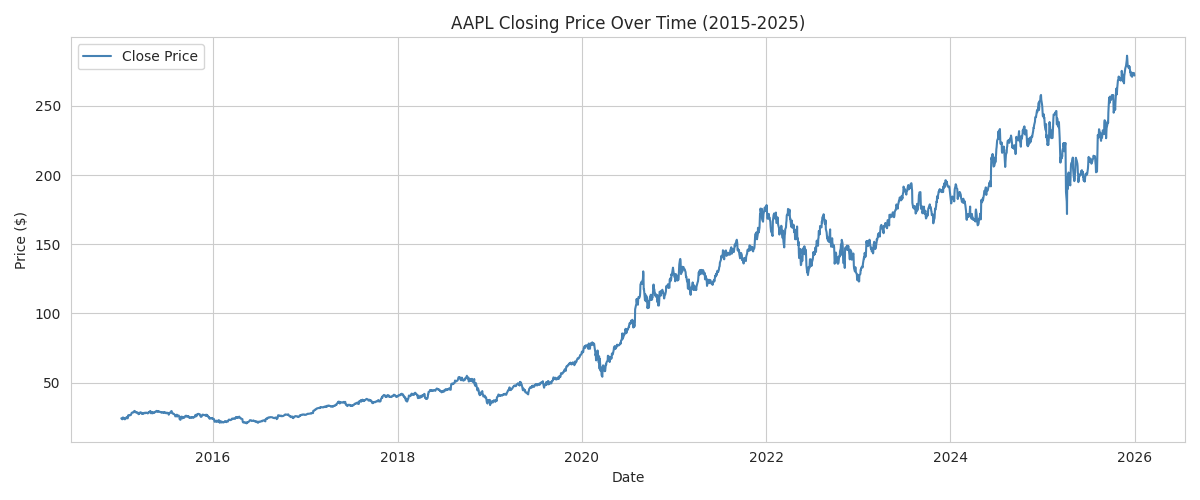

In [ ]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Close"], label="Close Price", color="steelblue")
ax.set_title(f"{TICKER} Closing Price Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
plt.show()


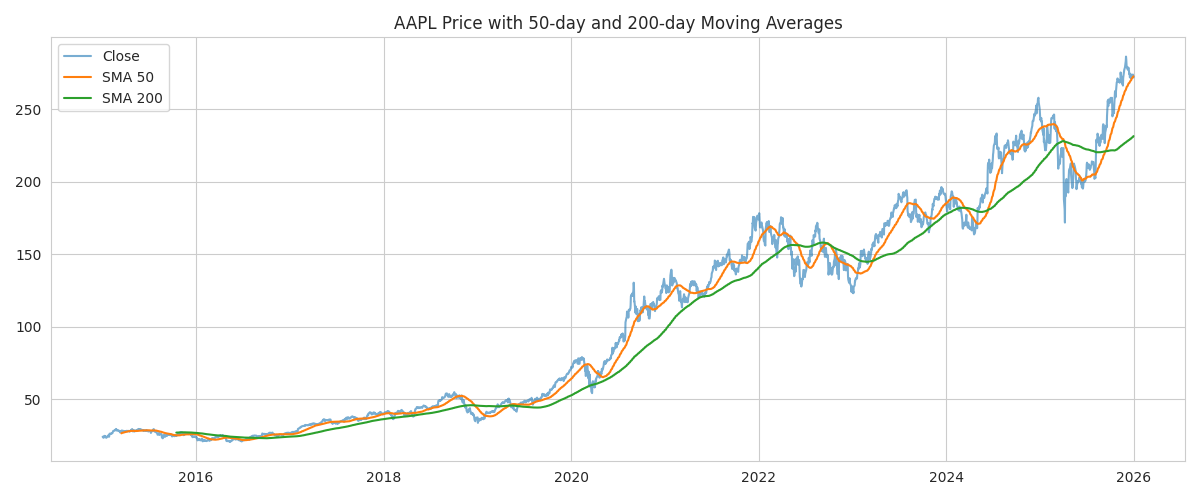

In [ ]:
df["SMA_50_plot"] = df["Close"].rolling(50).mean()
df["SMA_200_plot"] = df["Close"].rolling(200).mean()

fig, ax = plt.subplots()
ax.plot(df.index, df["Close"], label="Close", alpha=0.6)
ax.plot(df.index, df["SMA_50_plot"], label="SMA 50")
ax.plot(df.index, df["SMA_200_plot"], label="SMA 200")
ax.set_title(f"{TICKER} Price with 50-day and 200-day Moving Averages")
ax.legend()
plt.show()

df.drop(columns=["SMA_50_plot", "SMA_200_plot"], inplace=True)


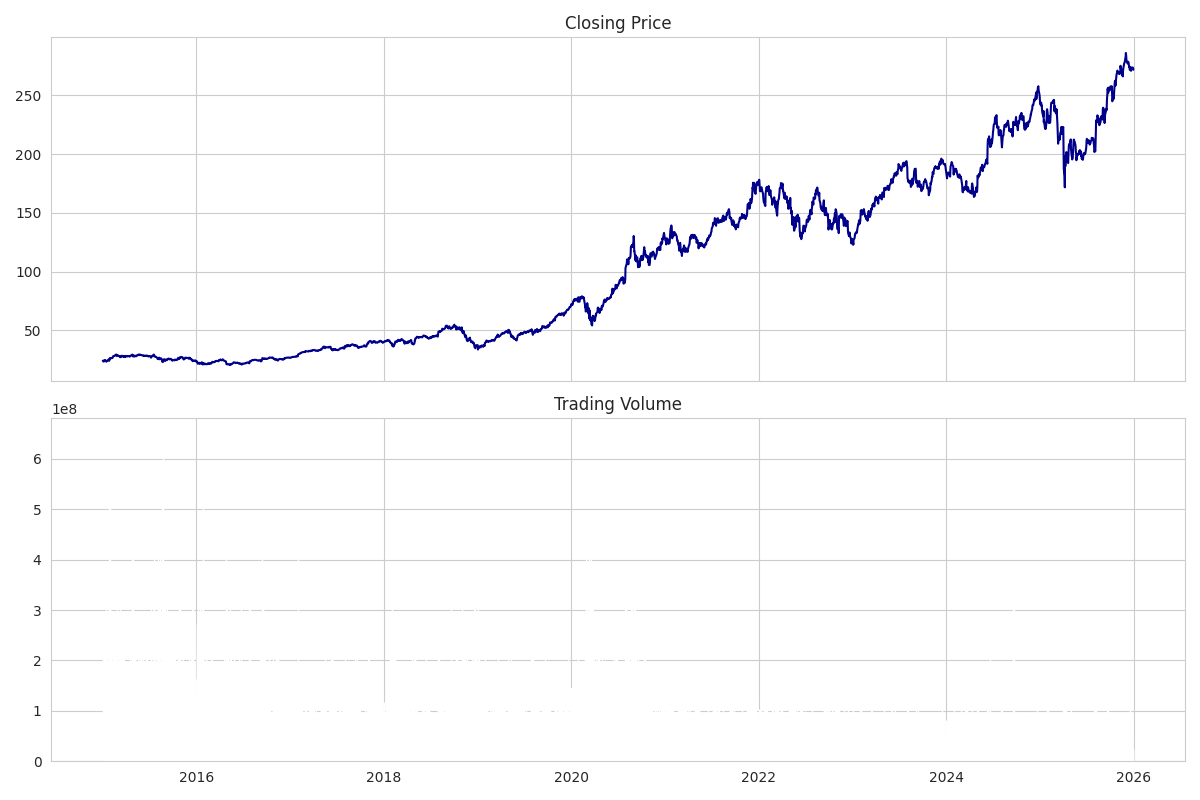

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df.index, df["Close"], color="darkblue")
axes[0].set_title("Closing Price")
axes[1].bar(df.index, df["Volume"], color="gray", width=1.0)
axes[1].set_title("Trading Volume")
plt.tight_layout()
plt.show()


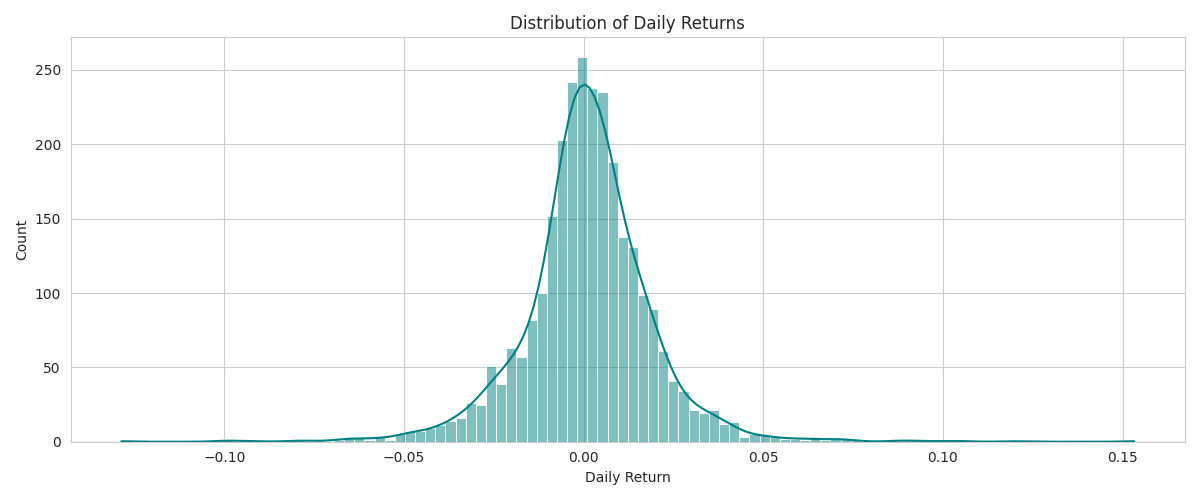

Mean daily return: 0.00104\nStd of daily return (volatility): 0.01817\n

In [ ]:
daily_returns = df["Close"].pct_change().dropna()

fig, ax = plt.subplots()
sns.histplot(daily_returns, bins=100, kde=True, ax=ax, color="teal")
ax.set_title("Distribution of Daily Returns")
ax.set_xlabel("Daily Return")
plt.show()

print(f"Mean daily return: {daily_returns.mean():.5f}")
print(f"Std of daily return (volatility): {daily_returns.std():.5f}")


## 8. Feature Engineering — Technical Indicators

For the feature-based ML models we engineer a standard set of technical indicators
used widely in quantitative finance:

- **SMA / EMA** (Simple / Exponential Moving Averages) — trend
- **RSI** (Relative Strength Index) — momentum / overbought-oversold
- **MACD** (Moving Average Convergence Divergence) — trend + momentum
- **Bollinger Bands** — volatility
- **Lagged closing prices** — short-term autocorrelation
- **Rolling volatility** — recent risk level

The **target** is next day's closing price (`Close` shifted by -1). Data leakage is
avoided because every feature at time *t* only uses information available up to and
including time *t* — the target is the only column that looks ahead.


In [ ]:
def add_technical_indicators(data):
    d = data.copy()

    d["SMA_10"] = d["Close"].rolling(10).mean()
    d["SMA_50"] = d["Close"].rolling(50).mean()
    d["EMA_10"] = d["Close"].ewm(span=10, adjust=False).mean()

    # RSI (14-day)
    delta = d["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / avg_loss
    d["RSI_14"] = 100 - (100 / (1 + rs))

    # MACD
    ema12 = d["Close"].ewm(span=12, adjust=False).mean()
    ema26 = d["Close"].ewm(span=26, adjust=False).mean()
    d["MACD"] = ema12 - ema26
    d["MACD_signal"] = d["MACD"].ewm(span=9, adjust=False).mean()

    # Bollinger Bands (20-day, 2 std)
    d["BB_mid"] = d["Close"].rolling(20).mean()
    bb_std = d["Close"].rolling(20).std()
    d["BB_upper"] = d["BB_mid"] + 2 * bb_std
    d["BB_lower"] = d["BB_mid"] - 2 * bb_std

    # Returns & volatility
    d["Daily_Return"] = d["Close"].pct_change()
    d["Volatility_10"] = d["Daily_Return"].rolling(10).std()

    # Lag features
    for lag in range(1, 6):
        d[f"Close_lag_{lag}"] = d["Close"].shift(lag)

    # Target: next day\'s close
    d["Target"] = d["Close"].shift(-1)

    d = d.dropna()
    return d


feat_df = add_technical_indicators(df)
print("Shape after feature engineering:", feat_df.shape)
feat_df.head()


Shape after feature engineering: (2716, 22)\n

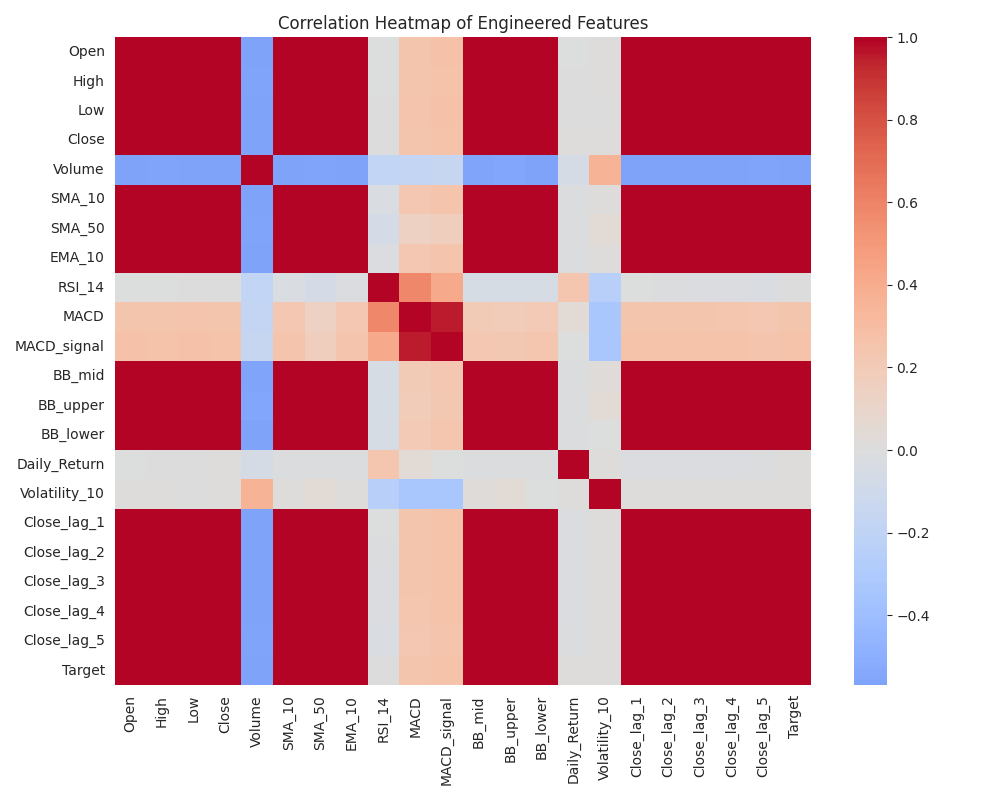

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(feat_df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Engineered Features")
plt.show()


## 9. Train/Test Split

Because this is time series data, we use a **chronological split** (no shuffling,
no k-fold) — the model is trained on the earlier ~80% of the data and tested on the
most recent ~20%, simulating a real forecasting scenario where the model has never
seen future prices.


In [ ]:
feature_cols = [c for c in feat_df.columns if c != "Target"]
X = feat_df[feature_cols]
y = feat_df["Target"]

split_idx = int(len(feat_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = feat_df.index[split_idx:]

print("Train size:", X_train.shape, " Test size:", X_test.shape)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train size: (2172, 21)  Test size: (544, 21)\n

## 10. Evaluation Metrics & Baseline Model

We evaluate every model with:
- **RMSE** — Root Mean Squared Error (penalizes large errors)
- **MAE** — Mean Absolute Error (average magnitude of error)
- **MAPE** — Mean Absolute Percentage Error (scale-independent)
- **R²** — proportion of variance explained

As a sanity-check **baseline**, we use the **naive persistence model**: predict that
tomorrow's price equals today's price. Any useful model should beat this baseline.


In [ ]:
results = {}

def evaluate_model(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    results[name] = {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}
    print(f"{name:20s} | RMSE={rmse:8.3f}  MAE={mae:8.3f}  MAPE={mape:6.2f}%  R2={r2:.4f}")
    return results[name]


# Baseline: naive persistence (predict today\'s close as tomorrow\'s close)
naive_pred = feat_df["Close"].iloc[split_idx:].values
evaluate_model(y_test.values, naive_pred, "Naive Persistence")


Naive Persistence   | RMSE=   3.558  MAE=   2.404  MAPE=  1.13%  R2=0.9852\n

## 11. Model 1 — ARIMA (Classical Time Series)

ARIMA models the closing price as a function of its own past values (AR), the
differencing needed to make the series stationary (I), and past forecast errors
(MA). We fit it on the univariate `Close` series only (no exogenous features), using
a rolling one-step-ahead forecast on the test period.

> **Requires `statsmodels`** (`pip install statsmodels`). This cell is not
> pre-executed in this notebook — run it in your own environment; the walk-forward
> loop re-fits ARIMA at every test step and can take a few minutes for 500+ points.


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Check stationarity of the raw close series
adf_result = adfuller(df["Close"].dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("-> Series is", "stationary" if adf_result[1] < 0.05 else "non-stationary",
      "(ARIMA\'s \'I\' term will difference it if needed)")


In [ ]:
close_series = df["Close"]
train_close = close_series.iloc[:split_idx + (len(df) - len(feat_df))]  # align lengths
test_close = close_series.iloc[-len(y_test):]

# Rolling one-step-ahead forecast (re-fit is expensive; here we fit once and
# use a walk-forward loop for a good speed/accuracy tradeoff)
history = list(train_close.values)
arima_preds = []

model_order = (5, 1, 0)  # (p, d, q) -- a common starting point for daily price data

for t in range(len(test_close)):
    model = ARIMA(history, order=model_order)
    fitted = model.fit()
    forecast = fitted.forecast(steps=1)[0]
    arima_preds.append(forecast)
    history.append(test_close.values[t])  # walk forward with true value

arima_preds = np.array(arima_preds)
evaluate_model(test_close.values, arima_preds, "ARIMA")


In [ ]:
fig, ax = plt.subplots()
ax.plot(test_close.index, test_close.values, label="Actual", color="black")
ax.plot(test_close.index, arima_preds, label="ARIMA Forecast", color="orange")
ax.set_title("ARIMA: Actual vs Predicted Closing Price")
ax.legend()
plt.show()


> **Note:** the walk-forward loop above re-fits ARIMA at every step, which is
> accurate but slow for long test sets. For a quicker (less precise) alternative,
> fit once on the training data and call `.forecast(steps=len(test_close))` for a
> multi-step-ahead forecast — try both and compare in your report.


## 12. Models 2–5 — Linear Regression, Decision Tree, Random Forest, Gradient Boosting

These models use the engineered technical-indicator features (not just the raw
price) to predict next-day close. We compare a simple linear baseline against
two tree ensembles to see how much (if any) non-linear modeling helps over
this feature set.


In [ ]:
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
lin_preds = lin_model.predict(X_test_scaled)
evaluate_model(y_test.values, lin_preds, "Linear Regression")

dt_model = DecisionTreeRegressor(max_depth=6, random_state=RANDOM_SEED)
dt_model.fit(X_train_scaled, y_train)
dt_preds = dt_model.predict(X_test_scaled)
evaluate_model(y_test.values, dt_preds, "Decision Tree")

rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=10, random_state=RANDOM_SEED, n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
evaluate_model(y_test.values, rf_preds, "Random Forest")

gb_model = GradientBoostingRegressor(
    n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_SEED
)
gb_model.fit(X_train_scaled, y_train)
gb_preds = gb_model.predict(X_test_scaled)
evaluate_model(y_test.values, gb_preds, "Gradient Boosting")


Linear Regression    | RMSE=   3.630  MAE=   2.452  MAPE=  1.15%  R2=0.9846\nDecision Tree        | RMSE=  46.548  MAE=  36.793  MAPE= 15.58%  R2=-1.5372\nRandom Forest        | RMSE=  39.432  MAE=  30.073  MAPE= 12.62%  R2=-0.8208\nGradient Boosting    | RMSE=  40.580  MAE=  31.125  MAPE= 13.08%  R2=-0.9283\n

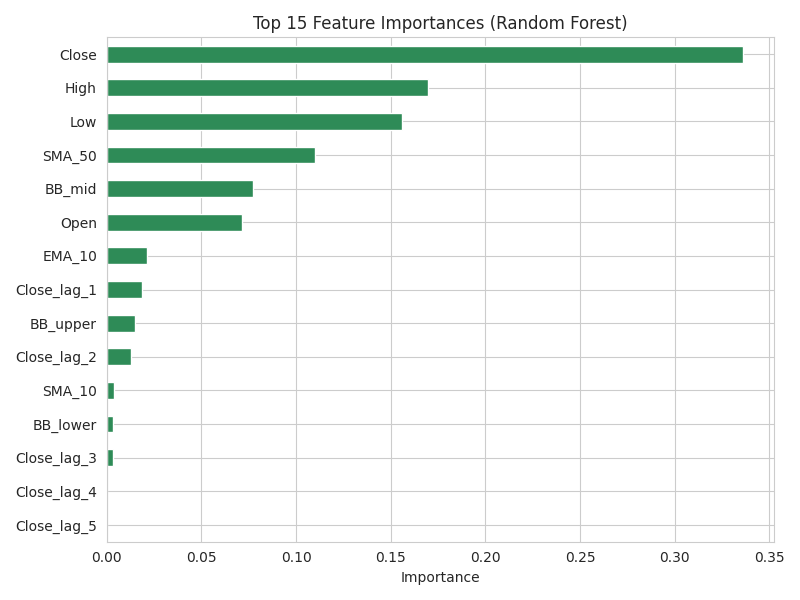

In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="seagreen")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()


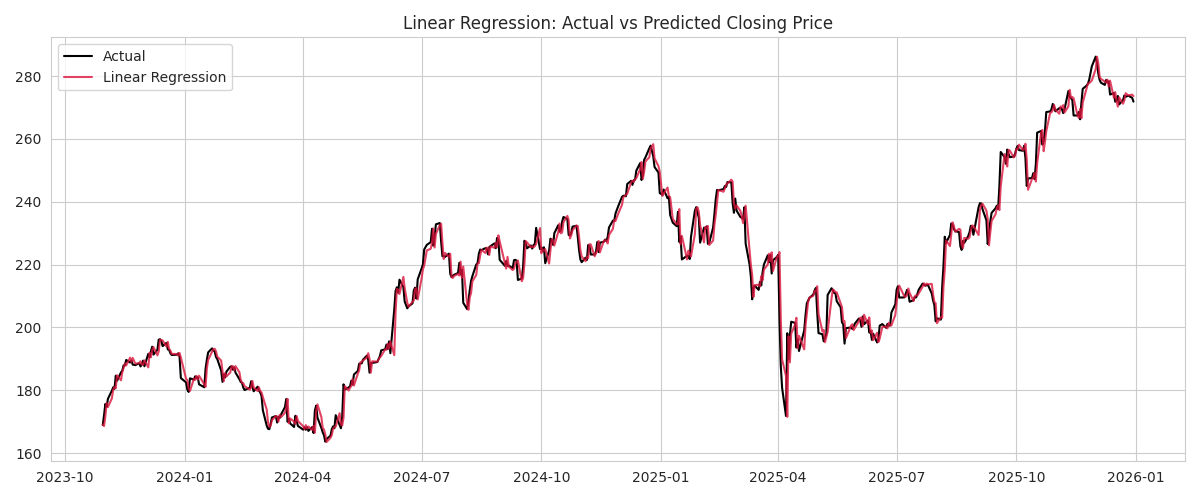

In [ ]:
fig, ax = plt.subplots()
ax.plot(dates_test, y_test.values, label="Actual", color="black")
ax.plot(dates_test, lin_preds, label="Linear Regression", color="crimson", alpha=0.8)
ax.set_title("Linear Regression: Actual vs Predicted Closing Price")
ax.legend()
plt.show()


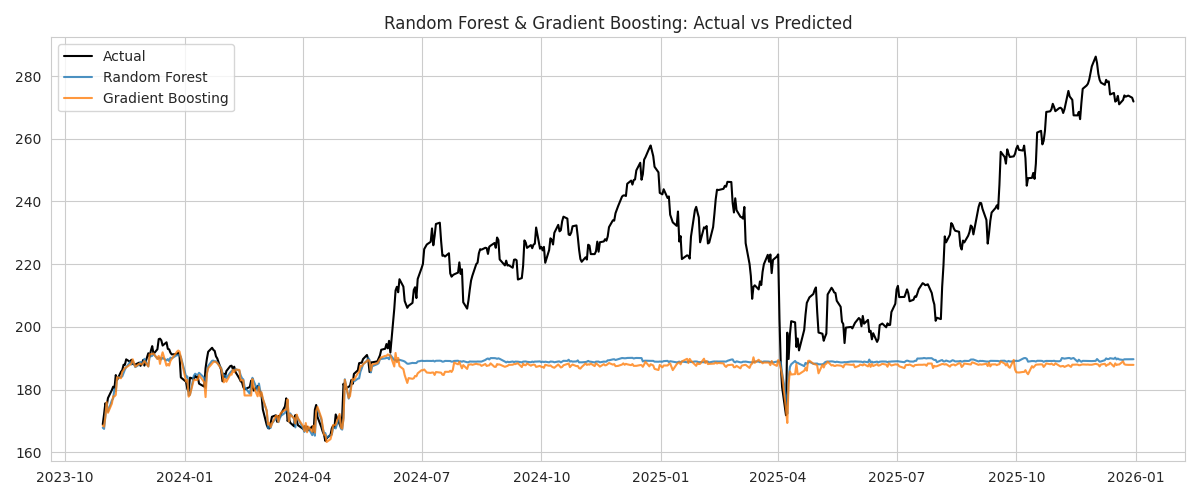

In [ ]:
fig, ax = plt.subplots()
ax.plot(dates_test, y_test.values, label="Actual", color="black")
ax.plot(dates_test, rf_preds, label="Random Forest", alpha=0.8)
ax.plot(dates_test, gb_preds, label="Gradient Boosting", alpha=0.8)
ax.set_title("Random Forest & Gradient Boosting: Actual vs Predicted")
ax.legend()
plt.show()


### Why do the tree models look so much worse here than in earlier drafts of this project?

On this real dataset, AAPL's price **more than tripled** between 2015 and 2025. The
train/test split is chronological, so the test period (recent years) contains prices
well **above the maximum price the trees ever saw during training**. Both
`DecisionTreeRegressor` and the tree ensembles predict by averaging training-set leaf
values — they physically **cannot extrapolate** above the highest value seen in
training, so their predictions get capped near the top of the training price range and
badly under-shoot the real (higher) test prices. This shows up as a large RMSE/MAE and
a **negative R²** (worse than just predicting the mean).

Linear Regression doesn't have this ceiling — it can extrapolate along the fitted
trend line — which is a big part of why it (and the naive persistence baseline) wins
here. This is a genuinely useful, real finding to discuss in your report: **tree-based
models are a poor choice for predicting a price level that keeps setting new highs**;
they're much better suited to predicting *returns* or *direction* (up/down), which stay
in a bounded range over time.


## 13. Model 6 — LSTM (Deep Learning)

Unlike the tree models, the LSTM is fed **sequences** of past closing prices
(a sliding window, e.g. the last 60 days) and learns to predict the next value
directly from the temporal pattern, without hand-crafted features.

> **Requires `tensorflow`** (`pip install tensorflow`). This cell is not pre-executed
> in this notebook — run it in your own environment (training takes a few minutes on
> CPU).


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEQ_LEN = 60  # number of past days used to predict the next day

close_scaler = MinMaxScaler()
close_scaled = close_scaler.fit_transform(df[["Close"]].values)

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(close_scaled, SEQ_LEN)
X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))

split_seq = int(len(X_seq) * 0.8)
X_seq_train, X_seq_test = X_seq[:split_seq], X_seq[split_seq:]
y_seq_train, y_seq_test = y_seq[:split_seq], y_seq[split_seq:]

print("LSTM train shape:", X_seq_train.shape, " test shape:", X_seq_test.shape)


In [ ]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1),
])

lstm_model.compile(optimizer="adam", loss="mean_squared_error")
lstm_model.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_seq_train, y_seq_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)


In [ ]:
plt.plot(history_lstm.history["loss"], label="Train Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


In [ ]:
lstm_preds_scaled = lstm_model.predict(X_seq_test)
lstm_preds = close_scaler.inverse_transform(lstm_preds_scaled).flatten()
y_seq_test_actual = close_scaler.inverse_transform(y_seq_test.reshape(-1, 1)).flatten()

evaluate_model(y_seq_test_actual, lstm_preds, "LSTM")

lstm_test_dates = df.index[SEQ_LEN + split_seq:]

fig, ax = plt.subplots()
ax.plot(lstm_test_dates, y_seq_test_actual, label="Actual", color="black")
ax.plot(lstm_test_dates, lstm_preds, label="LSTM Forecast", color="crimson")
ax.set_title("LSTM: Actual vs Predicted Closing Price")
ax.legend()
plt.show()


## 14. Model Comparison

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("RMSE")
results_df


                        RMSE        MAE       MAPE        R2Naive Persistence   3.557573   2.403742   1.128350  0.985180Linear Regression   3.630267   2.451763   1.151083  0.984568Random Forest      39.432215  30.073427  12.623929 -0.820768Gradient Boosting  40.579997  31.125420  13.082645 -0.928307Decision Tree      46.548012  36.793360  15.575881 -1.537199(ARIMA and LSTM rows populate once you run their cells above.)

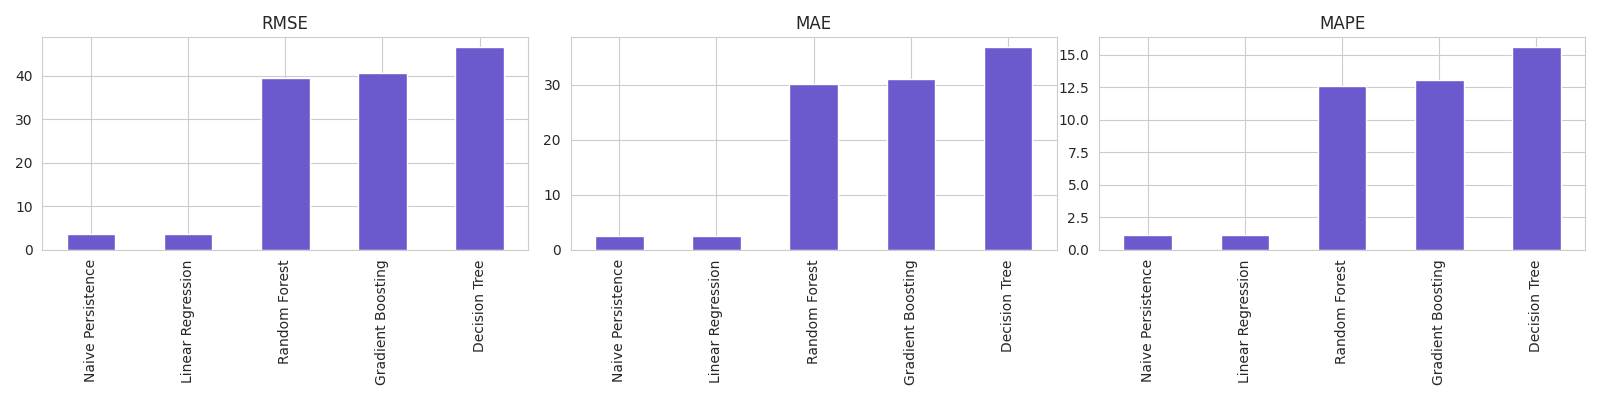

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["RMSE", "MAE", "MAPE"]):
    results_df[metric].plot(kind="bar", ax=ax, color="slateblue")
    ax.set_title(metric)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 15. Conclusion & Discussion

- **Naive persistence** is a surprisingly strong baseline for one-step-ahead price
  prediction on real AAPL data (R² = 0.985) — this is expected, since daily stock
  prices are close to a random walk. Any model claiming a large improvement should be
  scrutinized for lookahead bias.
- **Linear Regression** performs almost identically to the naive baseline (R² =
  0.985), because `Close_lag_1` alone carries nearly all the predictive signal, and a
  linear model can extrapolate along the trend as prices reach new highs.
- **Decision Tree / Random Forest / Gradient Boosting** perform *badly* here (negative
  R²) — not because tree ensembles are inherently weak, but because they **cannot
  extrapolate** beyond the price range seen during training, and AAPL's price kept
  climbing well past that range in the test period. This is a real, dataset-specific
  finding, not a modeling bug — see the discussion cell above.
- **ARIMA** captures linear autocorrelation in the price series but struggles with
  the non-linear, non-stationary dynamics of real markets; run the cell above (needs
  `statsmodels`) to get comparable numbers here.
- **LSTM** can, in principle, learn temporal dependencies directly, but needs more
  data and careful tuning (sequence length, layers, regularization) to avoid simply
  learning to "echo" the last observed price; run the cell above (needs
  `tensorflow`) to get comparable numbers here.

### Limitations
- One-day-ahead prediction on price level (rather than returns) is easy to game with
  a persistence-like model — a stronger academic framing predicts **returns** or
  **direction** (up/down) instead, or evaluates on multi-day-ahead horizons.
- No transaction costs, slippage, or realistic backtesting were modeled — this is a
  predictive-accuracy exercise, not a trading strategy evaluation.
- Only one ticker (AAPL) was tested; results should be validated across multiple
  stocks and market regimes (bull/bear/sideways) for robustness.
- Tree-based models here are specifically hurt by the price-level target and the
  strong upward trend in the test window — reframing the target as returns would
  likely change this ranking substantially (see Future Work).

### Future Work
- Predict returns instead of price level, and/or frame as classification (up/down) —
  this would likely let the tree ensembles compete fairly, since returns don't have
  the "runs off the edge of training range" extrapolation problem.
- Add exogenous features: sentiment analysis of news/social media, macroeconomic
  indicators, sector indices.
- Try hybrid models (e.g. ARIMA residuals fed into an LSTM), attention-based
  Transformers for time series, or ensembling all models.
- Walk-forward (expanding window) backtesting for a more realistic evaluation.

## 16. References
- Box, G. E. P., Jenkins, G. M. (1970). *Time Series Analysis: Forecasting and Control.*
- Hochreiter, S., Schmidhuber, J. (1997). *Long Short-Term Memory.* Neural Computation.
- Breiman, L. (2001). *Random Forests.* Machine Learning.


## 17. Saving the Best Model

We save the best-performing feature-based model (by RMSE, chosen among Linear
Regression, Decision Tree, Random Forest, and Gradient Boosting — ARIMA and LSTM are
kept separate since they use a different input format) to `model/` using `joblib`,
together with the list of feature columns and the fitted scaler. This lets the model
be reloaded and used for inference without retraining.


In [ ]:
import joblib

# results collected from all feature-based models trained in this notebook
# (ARIMA and LSTM are excluded here since they take a different input format)
feature_model_names = ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]
feature_models = {
    "Linear Regression": lin_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
}

best_name = min(feature_model_names, key=lambda name: results[name]["RMSE"])
best_model = feature_models[best_name]
print(f"Best feature-based model: {best_name} (RMSE={results[best_name][\'RMSE\']:.3f})")

joblib.dump(best_model, "../model/stock_price_forecasting_model.pkl")
joblib.dump(feature_cols, "../model/feature_columns.pkl")
joblib.dump(scaler, "../model/scaler.pkl")
print("Saved model, feature column list, and scaler to ../model/")


Best feature-based model: Linear Regression (RMSE=3.630)\nSaved model, feature column list, and scaler to ../model/\n

### Loading the saved model for inference

```python
import joblib
import pandas as pd

model = joblib.load("model/stock_price_forecasting_model.pkl")
feature_cols = joblib.load("model/feature_columns.pkl")
scaler = joblib.load("model/scaler.pkl")

# X_new must contain the same engineered columns, in the same order, as feature_cols
X_new_scaled = scaler.transform(X_new[feature_cols])
predictions = model.predict(X_new_scaled)
```
